# Gradient Norm Curves — Individual Sample Analysis
Visualises per-epoch gradient norms for selected T12-missing and T13-extra mislabeled samples,
with CT vertebra patch insets (middle sagittal slice). 

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

with open("../results/glare/19-08-26_21:11_ep-8_single-gpu/results/grad_norms_20260819_211102.pkl", "rb") as f:
    gn = pickle.load(f)

CLASS_NAMES = {0: "Cervical", 1: "Thoracic", 2: "Lumbar", 3: "Sacral"}
N_EPOCHS = 8
PREPARED = "../prepared"
FIGURES_DIR = "."

def get_grad_norms(sample_id):
    rows = gn[gn["id"] == sample_id].sort_values("epoch")
    return rows[["c0_grad_norm", "c1_grad_norm", "c2_grad_norm", "c3_grad_norm"]].values

def load_ct_slice(npz_path):
    img = np.load(npz_path)["img"]
    mid_d = img.shape[0] // 2
    slc = img[mid_d, :, :]
    ch, cw = slc.shape[0] // 2, slc.shape[1] // 2
    half = 50
    return slc[ch - half : ch + half, cw - half : cw + half]

def plot_samples(samples, save_as=None):
    """Plot gradient norm curves for 2 or 3 samples side by side.
    Each sample tuple: (sample_id, assigned, true_cls, alt_cls, score, npz_path)
    For clean samples set assigned == true_cls; set alt_cls to show a competing class or -1 to hide.
    """
    n = len(samples)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4.5))
    if n == 1:
        axes = [axes]

    for ax, (sid, assigned, true_cls, alt_cls, score, npz_path) in zip(axes, samples):
        norms = get_grad_norms(sid)
        epochs = np.arange(N_EPOCHS)
        pct = int(score / N_EPOCHS * 100)
        is_clean = (assigned == true_cls)

        ax.set_title(f"GLARE: {score} ({pct}%)", fontsize=11)

        if is_clean:
            ax.plot(epochs, norms[:, assigned], color="green",
                    label=f"Label ({CLASS_NAMES[assigned]})", linewidth=1.8)
            if alt_cls >= 0 and alt_cls != assigned:
                ax.plot(epochs, norms[:, alt_cls], color="blue",
                        label=f"GLARE Alt. ({CLASS_NAMES[alt_cls]})",
                        linewidth=1.8, linestyle="--")
        else:
            ax.plot(epochs, norms[:, assigned], color="red",
                    label=f"Label ({CLASS_NAMES[assigned]})", linewidth=1.8)

            if alt_cls == true_cls:
                true_label = (f"True Label ({CLASS_NAMES[true_cls]}) /\n"
                              f"GLARE Alt. ({CLASS_NAMES[alt_cls]})")
            else:
                true_label = f"True Label ({CLASS_NAMES[true_cls]})"
            ax.plot(epochs, norms[:, true_cls], color="green",
                    label=true_label, linewidth=1.8)

            if alt_cls != true_cls and score < N_EPOCHS:
                ax.plot(epochs, norms[:, alt_cls], color="blue",
                        label=f"GLARE Alt. ({CLASS_NAMES[alt_cls]})",
                        linewidth=1.8, linestyle="--")

        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel("Gradient Norm", fontsize=10)
        ax.set_xticks(epochs)
        ax.set_ylim(0, 100)
        ax.legend(fontsize=9, loc="upper right")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        inset = ax.inset_axes([0.01, 0.62, 0.28, 0.36])
        slc = load_ct_slice(f"{PREPARED}/{npz_path}")
        inset.imshow(slc, cmap="gray", aspect="equal")
        inset.axis("off")

    plt.tight_layout()

    if save_as:
        out_path = os.path.join(FIGURES_DIR, save_as)
        fig.savefig(out_path, format="pdf", bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()

print("Ready. Loaded", len(gn), "rows.")

Ready. Loaded 154128 rows.


## T12-missing
Both samples: assigned = Thoracic (1, wrong), true = Lumbar (2)  
Physical patch = vert20 (mapped to vert19 by Rule-B correction)
- **Left**: `verse626_dir-iso_vert19` — GLARE score 0 → detected
- **Right**: `ID0387_ses-25062010_ce-pv_vert19` — GLARE score 6 → missed

Saved: ./grad_norm_T12_missing.pdf


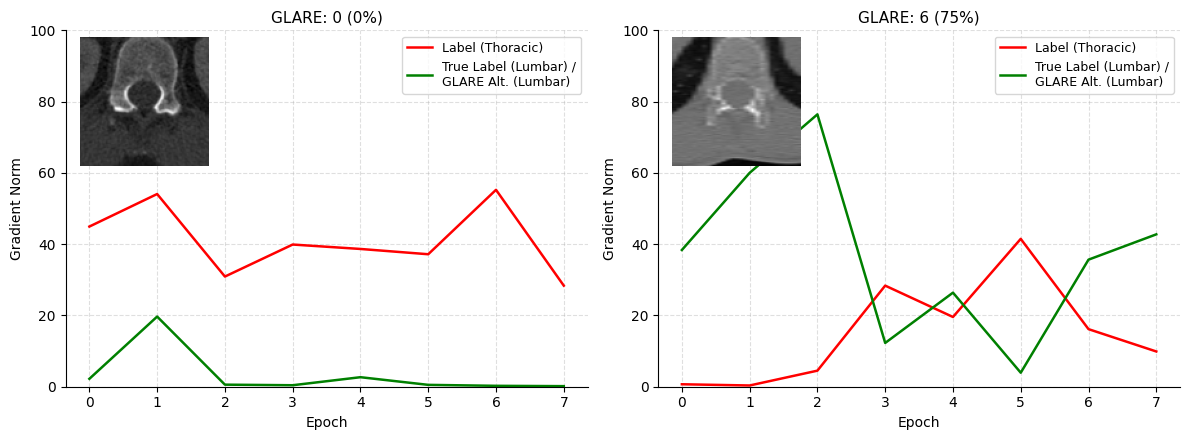

In [2]:
T12_SAMPLES = [
    ("verse626_dir-iso_vert19",          1, 2, 2, 0,
     "dataset-verse20/train/segment0.8mm_vert20_sub-verse626_dir-iso.npz"),
    ("ID0387_ses-25062010_ce-pv_vert19", 1, 2, 2, 6,
     "dataset-sagthomas/train/segment0.8mm_vert20_sub-ID0387_ses-25062010_ce-pv.npz"),
]

plot_samples(T12_SAMPLES, save_as="grad_norm_T12_missing.pdf")

## T13-extra
Both samples: assigned = Lumbar (2, wrong), true = Thoracic (1)  
- **Left**: `ctfu00897_ses-20170303_ce-art_vert20` — GLARE score 0 → detected (rare)  
  Physical patch = vert28 (T13 mapped to vert20 by Rule-A correction)  
- **Right**: `ID0260_ses-02022011_ce-pv_vert20` — GLARE score 8 → undetected (typical)  
  Physical patch = vert20 (no correction applied)  
  Note: GLARE alt class shows Cervical (0) — artifact of all alt counts tied at 0.

## Correctly labeled samples
Both: assigned = Lumbar (2, correct), true = Lumbar (2), vert20  
- **Left**: `ATL057_dir-sag_split-WS_vert20` — GLARE score 7 → labeled class lowest in 7/8 epochs  
- **Right**: `ATL028_dir-sag_split-WS_vert20` — GLARE score 8 → labeled class lowest all 8 epochs

Saved: ./6.1_grad_norm_correct.pdf


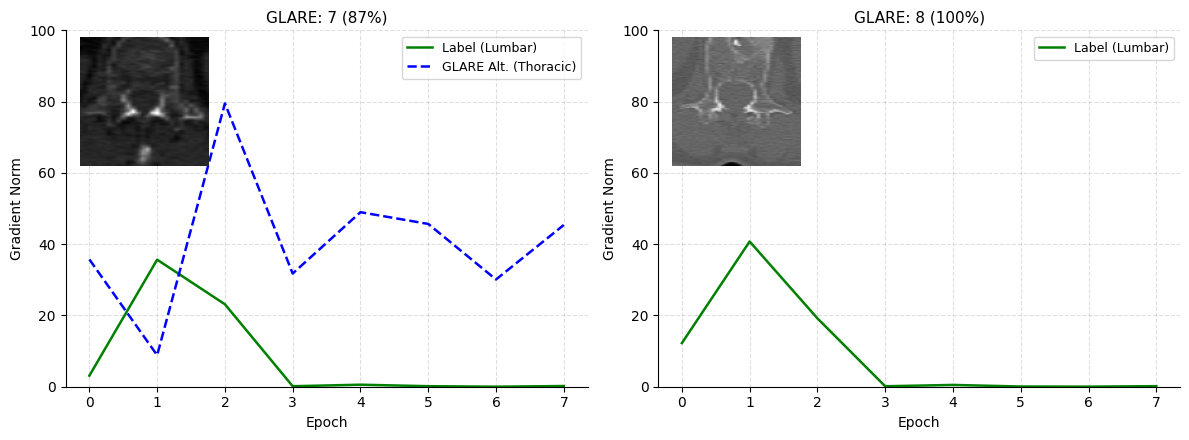

In [3]:
CLEAN_SAMPLES = [
    ("ATL057_dir-sag_split-WS_vert20", 2, 2, 1, 7,
     "dataset-ATL/train/segment0.8mm_vert20_sub-ATL057_dir-sag_split-WS.npz"),
    ("ATL028_dir-sag_split-WS_vert20", 2, 2, -1, 8,
     "dataset-ATL/train/segment0.8mm_vert20_sub-ATL028_dir-sag_split-WS.npz"),
]

plot_samples(CLEAN_SAMPLES, save_as="6.1_grad_norm_correct.pdf")

Saved: ./grad_norm_T13_extra.pdf


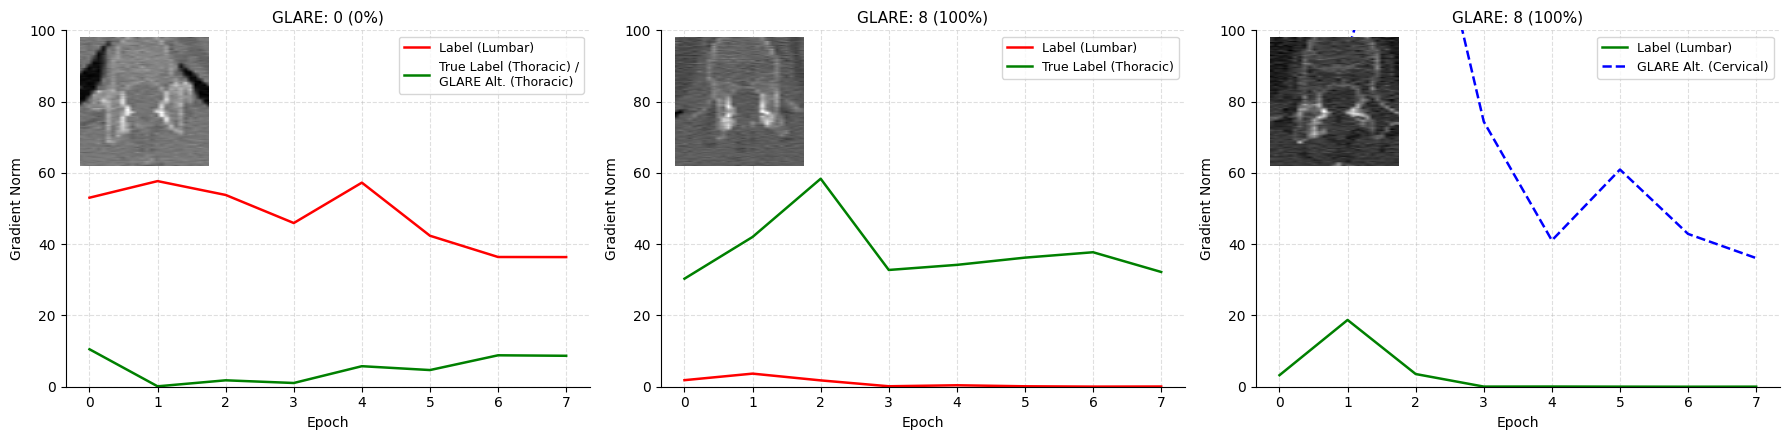

In [4]:
T13_SAMPLES = [
    ("ctfu00897_ses-20170303_ce-art_vert20", 2, 1, 1, 0,
     "dataset-ctfu1org/train/segment0.8mm_vert28_sub-ctfu00897_ses-20170303_ce-art.npz"),
    ("ID0260_ses-02022011_ce-pv_vert20",      2, 1, 0, 8,
     "dataset-sagthomas/train/segment0.8mm_vert20_sub-ID0260_ses-02022011_ce-pv.npz"),
    # Clean L1 (correctly labeled Lumbar, GLARE score 8)
    ("ID0009_ses-26102010_ce-pv_vert20",      2, 2, 0, 8,
     "dataset-sagthomas/train/segment0.8mm_vert20_sub-ID0009_ses-26102010_ce-pv.npz"),
]

plot_samples(T13_SAMPLES, save_as="grad_norm_T13_extra.pdf")

## GLARE vs GLAREx — Recall vs Fraction Checked

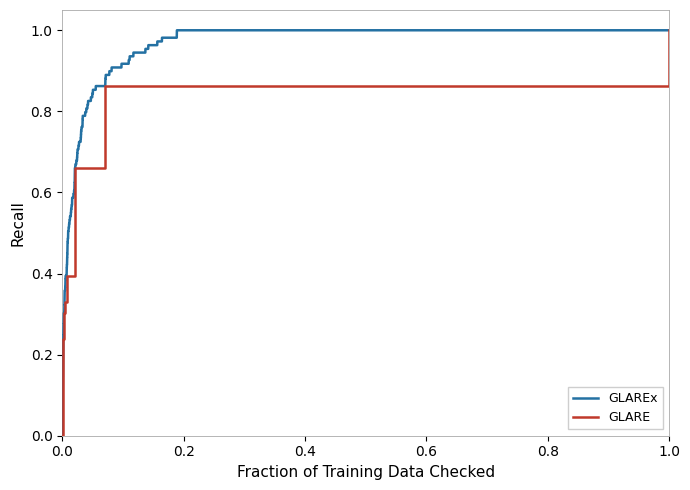

Total training samples: 19266 | GT mislabels: 109


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scores = pd.read_csv("../results/glare/19-08-26_21:11_ep-8_single-gpu/results/mislabels_list_20260819_211102.csv")
gt     = pd.read_excel("../evaluation/gt_mislabels_complete.xlsx")

gt_ids = set(gt["sample_id"].values)
scores["is_mislabel"] = scores["id"].isin(gt_ids)
total     = len(scores)
total_mis = int(scores["is_mislabel"].sum())

# GLAREx: smooth continuous curve
glarex_sorted = scores.sort_values("glarex score", ascending=True).reset_index(drop=True)
glarex_sorted["recall"] = glarex_sorted["is_mislabel"].cumsum() / total_mis
glarex_sorted["frac"]   = (glarex_sorted.index + 1) / total

# GLARE: step function at each integer score boundary (0–8)
glare_sorted = scores.sort_values("glare score", ascending=True).reset_index(drop=True)
glare_pts = [{"frac": 0.0, "recall": 0.0}]
for thr in range(9):
    subset = glare_sorted[glare_sorted["glare score"] <= thr]
    glare_pts.append({"frac": len(subset) / total,
                      "recall": subset["is_mislabel"].sum() / total_mis})
glare_df = pd.DataFrame(glare_pts)

COLOR_GLARE  = "#C0392B"
COLOR_GLAREX = "#2471A3"

fig, ax = plt.subplots(figsize=(7, 5))

# GLAREx smooth curve
ax.plot(glarex_sorted["frac"], glarex_sorted["recall"],
        color=COLOR_GLAREX, linewidth=1.8, zorder=3, label="GLAREx")

# GLARE step function — full range, same as Luca's style
ax.step(glare_df["frac"], glare_df["recall"],
        where="post", color=COLOR_GLARE, linewidth=1.8, zorder=4, label="GLARE")

ax.set_xlabel("Fraction of Training Data Checked", fontsize=11)
ax.set_ylabel("Recall", fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(False)
for sp in ax.spines.values():
    sp.set_linewidth(0.6)
    sp.set_color("#AAAAAA")
ax.legend(fontsize=9, loc="lower right", framealpha=0.95,
          edgecolor="#CCCCCC", fancybox=False)

plt.tight_layout()
plt.savefig("glare_glarex_recall_curve.pdf", bbox_inches="tight")
plt.savefig("glare_glarex_recall_curve.png", dpi=180, bbox_inches="tight")
plt.show()
print(f"Total training samples: {total} | GT mislabels: {total_mis}")

## GLARE vs GLAREx — F1 vs Fraction Checked

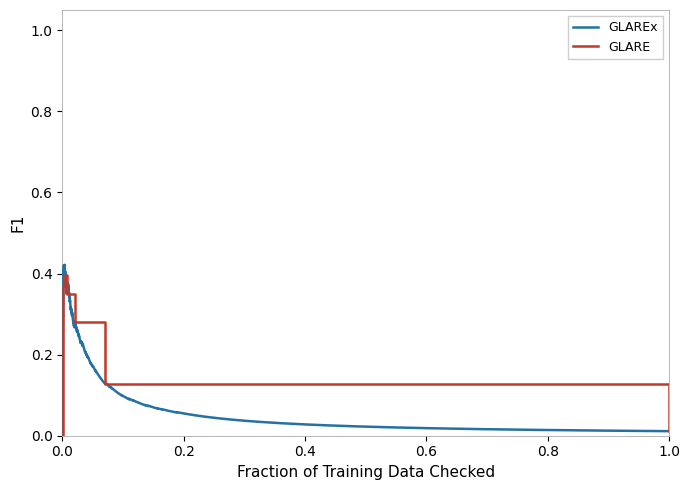

GLARE peak F1: 0.396 at frac 0.0038
GLAREx peak F1: 0.422 at frac 0.0039


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scores = pd.read_csv("../results/glare/19-08-26_21:11_ep-8_single-gpu/results/mislabels_list_20260819_211102.csv")
gt     = pd.read_excel("../evaluation/gt_mislabels_complete.xlsx")

gt_ids = set(gt["sample_id"].values)
scores["is_mislabel"] = scores["id"].isin(gt_ids)
total     = len(scores)
total_mis = int(scores["is_mislabel"].sum())

def f1_curve(sorted_df, total_mis, total):
    fracs, f1s = [0.0], [0.0]
    cum_tp = 0
    for i, row in enumerate(sorted_df.itertuples(), 1):
        cum_tp += int(row.is_mislabel)
        recall = cum_tp / total_mis
        prec   = cum_tp / i
        f1     = 2 * recall * prec / (recall + prec) if (recall + prec) > 0 else 0
        fracs.append(i / total)
        f1s.append(f1)
    return np.array(fracs), np.array(f1s)

glarex_sorted = scores.sort_values("glarex score", ascending=True).reset_index(drop=True)
gx_fracs, gx_f1 = f1_curve(glarex_sorted, total_mis, total)

glare_sorted = scores.sort_values("glare score", ascending=True).reset_index(drop=True)
glare_pts = [{"frac": 0.0, "f1": 0.0}]
for thr in range(9):
    subset = glare_sorted[glare_sorted["glare score"] <= thr]
    n  = len(subset)
    tp = int(subset["is_mislabel"].sum())
    recall = tp / total_mis
    prec   = tp / n if n > 0 else 0
    f1     = 2 * recall * prec / (recall + prec) if (recall + prec) > 0 else 0
    glare_pts.append({"frac": n / total, "f1": f1})
glare_df = pd.DataFrame(glare_pts)

COLOR_GLARE  = "#C0392B"
COLOR_GLAREX = "#2471A3"

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(gx_fracs, gx_f1,
        color=COLOR_GLAREX, linewidth=1.8, zorder=3, label="GLAREx")
ax.step(glare_df["frac"], glare_df["f1"],
        where="post", color=COLOR_GLARE, linewidth=1.8, zorder=4, label="GLARE")
ax.set_xlabel("Fraction of Training Data Checked", fontsize=11)
ax.set_ylabel("F1", fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(False)
for sp in ax.spines.values():
    sp.set_linewidth(0.6)
    sp.set_color("#AAAAAA")
ax.legend(fontsize=9, loc="upper right", framealpha=0.95,
          edgecolor="#CCCCCC", fancybox=False)
plt.tight_layout()
plt.savefig("glare_glarex_f1_curve.pdf", bbox_inches="tight")
plt.savefig("glare_glarex_f1_curve.png", dpi=180, bbox_inches="tight")
plt.show()
print(f"GLARE peak F1: {glare_df['f1'].max():.3f} at frac {glare_df.loc[glare_df['f1'].idxmax(),'frac']:.4f}")
print(f"GLAREx peak F1: {gx_f1.max():.3f} at frac {gx_fracs[gx_f1.argmax()]:.4f}")